<a href="https://colab.research.google.com/github/Tokhirjonov15/Menu_detector_AI/blob/main/menu_detector_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print('Hello World!')

Hello World!


In [2]:
from google.colab import drive
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image, UnidentifiedImageError
import os
import numpy as np

from torchvision.models import mobilenet_v2

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [51]:
# Define Dataset Path

DATASET_PATH = '/content/drive/MyDrive/food101_dataset'
print('Dataset_Path:', DATASET_PATH)

CUSTOM_CLASS_MAPPING = {
    'hamburger': 'hamburger',
    'hot_dog': 'hot_dog',
    'chocolate_cake': 'dessert',  # Label Grouping | Class Consolidation
    'cheesecake': 'dessert',      # Label Grouping | Class Consolidation
    'kebab': 'kebab',
    'pilaf': 'pilaf'
}

CLASSES = ['hamburger', 'hot_dog', 'dessert', 'kebab', 'pilaf']
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

print(NUM_CLASSES)
print(CLASS_TO_IDX)

# Data Augmentation and Transformation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224), # Randomly crop and resize
    transforms.RandomHorizontalFlip(), # Randomly flip horizontally
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

Dataset_Path: /content/drive/MyDrive/food101_dataset
5
{'hamburger': 0, 'hot_dog': 1, 'dessert': 2, 'kebab': 3, 'pilaf': 4}


In [30]:
# Custom Dataset Class

class FoodDataset(Dataset):
  def __init__(self, images, labels, transform=None):
    self.images = images
    self.labels = labels
    self.transform = transform

  def __len__(self):
    # print('Images_Length', len(self.images))
    return len(self.images)

  def __getitem__(self, idx):
    img_path = self.images[idx]
    # print('Image_Path', img_path)
    label = self.labels[idx]
    # print('Label', label)
    try:
      image = Image.open(img_path)
      if image.mode == 'P' or image.mode == "RGBA":
        image = image.convert('RGBA').convert('RGB')
      else:
        image = image.convert('RGB')
    except (UnidentifiedImageError, OSError):
      print(f"Skipping broken image: {img_path}")
      return self.__getitem__((idx + 1) % len(self.images))
    if self.transform:
      image = self.transform(image)
    return image, label

In [44]:
all_images = []
for original_class, mapped_class in CUSTOM_CLASS_MAPPING.items():
  class_path = os.path.join(DATASET_PATH, original_class)
  print('Class_Path', class_path)
  if not os.path.exists(class_path):
    print(f"Warning: {class_path} not found")
    continue
  for img in os.listdir(class_path):
    # Modified: Correctly include common image file extensions
    if img.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
      full_path = os.path.join(class_path, img)
      all_images.append((full_path, CLASS_TO_IDX[mapped_class]))

np.random.shuffle(all_images)
split = int(0.8 * len(all_images))
train_data = all_images[:split]
val_data = all_images[split:]

train_images, train_labels = zip(*train_data)
val_images, val_labels = zip(*val_data)

print(f"Total images collected: {len(all_images)}")
print("All_Images (first 3, if any):")
for i in range(min(3, len(all_images))):
    print(all_images[i])

dataset = FoodDataset(train_images, train_labels)
print(f"Dataset length (after fix): {len(dataset)}")
img, lbl = dataset[0]

Class_Path /content/drive/MyDrive/food101_dataset/hamburger
Class_Path /content/drive/MyDrive/food101_dataset/hot_dog
Class_Path /content/drive/MyDrive/food101_dataset/chocolate_cake
Class_Path /content/drive/MyDrive/food101_dataset/cheesecake
Class_Path /content/drive/MyDrive/food101_dataset/kebab
Class_Path /content/drive/MyDrive/food101_dataset/pilaf
Total images collected: 4100
All_Images (first 3, if any):
('/content/drive/MyDrive/food101_dataset/chocolate_cake/3576239.jpg', 2)
('/content/drive/MyDrive/food101_dataset/hamburger/2182615.jpg', 0)
('/content/drive/MyDrive/food101_dataset/chocolate_cake/2728721.jpg', 2)
Dataset length (after fix): 3280


In [59]:
from collections import Counter

# Extract labels from all_images
image_labels = [label for _, label in all_images]

# Count occurrences of each label
label_counts = Counter(image_labels)

print("Class distribution in the dataset:")
for class_idx, count in label_counts.items():
    class_name = [name for name, idx in CLASS_TO_IDX.items() if idx == class_idx][0]
    print(f"{class_name}: {count} images")


Class distribution in the dataset:
dessert: 2000 images
hamburger: 1000 images
kebab: 100 images
hot_dog: 1000 images


In [52]:
train_dataset = FoodDataset(train_images, train_labels, transform=train_transform)
val_dataset = FoodDataset(val_images, val_labels, transform=val_transform)

In [62]:
from collections import Counter

# Calculate class weights for WeightedRandomSampler
# This helps address the class imbalance identified.
class_counts = Counter(train_labels)
num_samples = len(train_labels)

class_weights = []
for i in range(NUM_CLASSES):
    # Using 1.0 / count to give higher weight to less frequent classes
    weight = 1.0 / class_counts.get(i, num_samples) # Use num_samples if class not found to avoid division by zero
    class_weights.append(weight)

sample_weights = [class_weights[label] for label in train_labels]
sampler = torch.utils.data.WeightedRandomSampler(sample_weights, num_samples, replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)


In [63]:
# pretrained model
model = mobilenet_v2(weights='IMAGENET1K_V1')
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES) # fine-tuning

In [64]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)
model = model.to(device)

device: cuda


In [65]:
criterion = nn.CrossEntropyLoss() # Loss Function  |  '70% burger', '30% hot dog'
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5) # Weight - Reduced learning rate and added weight decay
torch.backends.cudnn.benchmark = True  # Benchmark Setting | Trick

In [66]:
# Training Loop

NUM_EPOCHS = 20 # Increased number of epochs
best_accuracy = 0.0

for epoch in range(NUM_EPOCHS):
  model.train()
  running_loss = 0.0
  for images, labels in train_loader:  # forward and backward(backpropagation)
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()  # zero the gradient
    outputs = model(images)
    loss = criterion(outputs, labels)  # calculate loss
    loss.backward()
    optimizer.step()  # Adam optimizer
    running_loss += loss.item()  # track loss

  # Validation
  model.eval()
  correct = 0
  total = 0
  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      __, predicted = torch.max(outputs, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  val_acc = 100 * correct / total
  print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}], Loss: {running_loss / len(train_loader):.4f}, Validation Accuracy: {val_acc:.2f}%")

  if val_acc > best_accuracy:
    best_accuracy = val_acc
    torch.save(model.state_dict(), '/content/menu_detector.pth')
    print("Saved new best model!")

Epoch [1/20], Loss: 0.4974, Validation Accuracy: 94.15%
Saved new best model!
Epoch [2/20], Loss: 0.2742, Validation Accuracy: 94.63%
Saved new best model!
Epoch [3/20], Loss: 0.2192, Validation Accuracy: 94.39%
Epoch [4/20], Loss: 0.1899, Validation Accuracy: 94.76%
Saved new best model!
Epoch [5/20], Loss: 0.1595, Validation Accuracy: 94.76%
Epoch [6/20], Loss: 0.1739, Validation Accuracy: 94.02%
Epoch [7/20], Loss: 0.1563, Validation Accuracy: 95.73%
Saved new best model!
Epoch [8/20], Loss: 0.1578, Validation Accuracy: 95.12%
Epoch [9/20], Loss: 0.1359, Validation Accuracy: 94.63%
Epoch [10/20], Loss: 0.1199, Validation Accuracy: 94.63%
Epoch [11/20], Loss: 0.1290, Validation Accuracy: 95.61%
Epoch [12/20], Loss: 0.1267, Validation Accuracy: 94.88%
Epoch [13/20], Loss: 0.1075, Validation Accuracy: 95.37%
Epoch [14/20], Loss: 0.1223, Validation Accuracy: 94.76%
Epoch [15/20], Loss: 0.0989, Validation Accuracy: 95.61%
Epoch [16/20], Loss: 0.1000, Validation Accuracy: 94.88%
Epoch [17

device: cuda
Upload one or more images of your food


Saving burger.jpg to burger (5).jpg


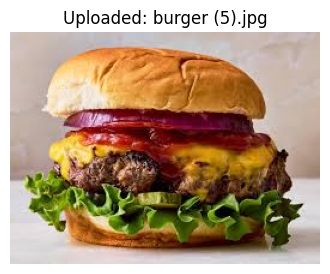

Prediction:
hamburger: 100.00%
kebab: 0.00%
dessert: 0.00%
pilaf: 0.00%


In [77]:
# Required Imports
import torch
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2
from PIL import Image
from google.colab import files
import io
import matplotlib.pyplot as plt

# Define Semantic Classes
CLASSES = ['hamburger', 'hot_dog', 'dessert', 'kebab', 'pilaf']  # Must match training order
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}

# Transform for Uploaded Images (no augmentations!)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load Model
model = mobilenet_v2(weights=None)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model.load_state_dict(torch.load('/content/menu_detector.pth', map_location='cpu'))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)
model = model.to(device)
model.eval()

# Upload Image
print('Upload one or more images of your food')
uploaded = files.upload()

for image_name in uploaded.keys():
  image = Image.open(io.BytesIO(uploaded[image_name])).convert('RGB')

  # Display Image
  plt.figure(figsize=(4, 4))
  plt.imshow(image)
  plt.axis('off')
  plt.title(f"Uploaded: {image_name}")
  plt.show()

  # Predict
  image_tensor = transform(image).unsqueeze(0).to(device)
  with torch.no_grad():
    output = model(image_tensor)
    probs = torch.softmax(output, dim=1)[0]
    topk = torch.topk(probs, 4)

  print('Prediction:')
  for i in range(topk.indices.size(0)):
    label = CLASSES[topk.indices[i]]
    confidence = topk.values[i].item() * 100
    print(f"{label}: {confidence:.2f}%")